# **DATA PREPRATION AND VISUALIZATION**

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [142]:
# Load Data
df = pd.read_csv("Dataset.csv", sep=";")

In [143]:
# Basic Data Info
print(df.info())
print(df.isnull().sum())
print(df.describe().T)
print(df['Target'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [144]:
# Encode target variable
df['Target'] = LabelEncoder().fit_transform(df['Target'])
print(df['Target'].value_counts())

Target
2    2209
0    1421
1     794
Name: count, dtype: int64


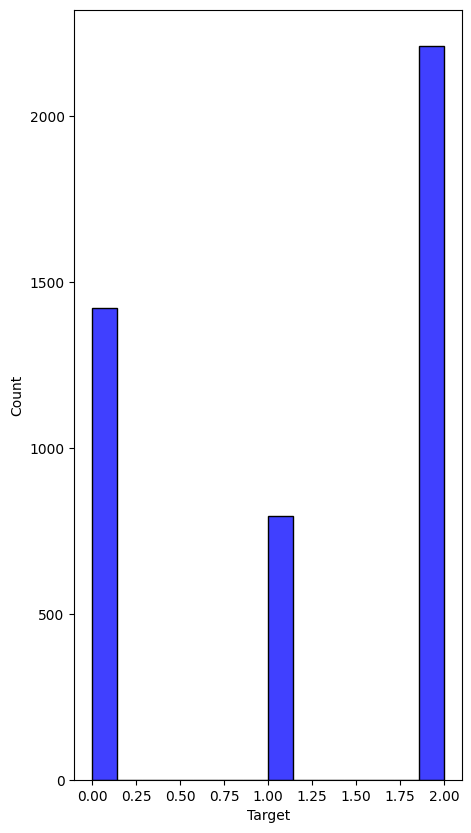

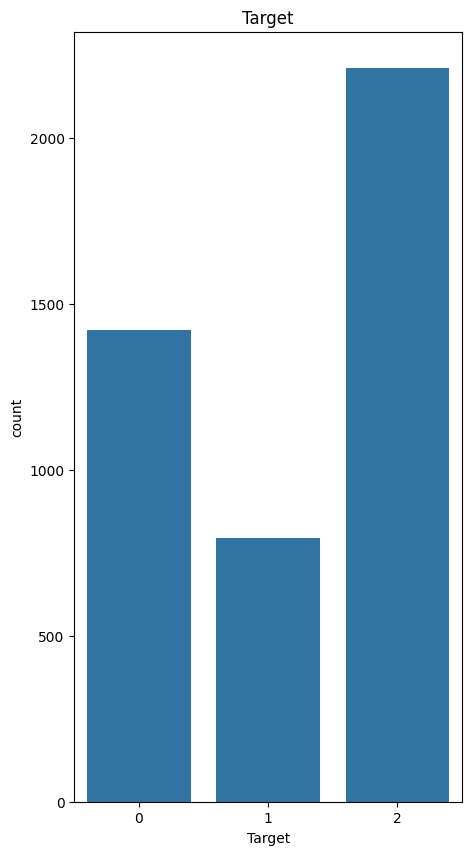

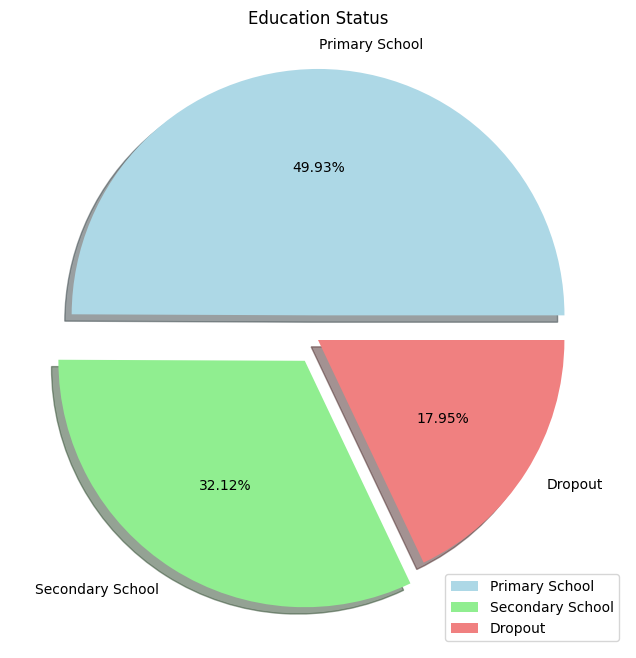

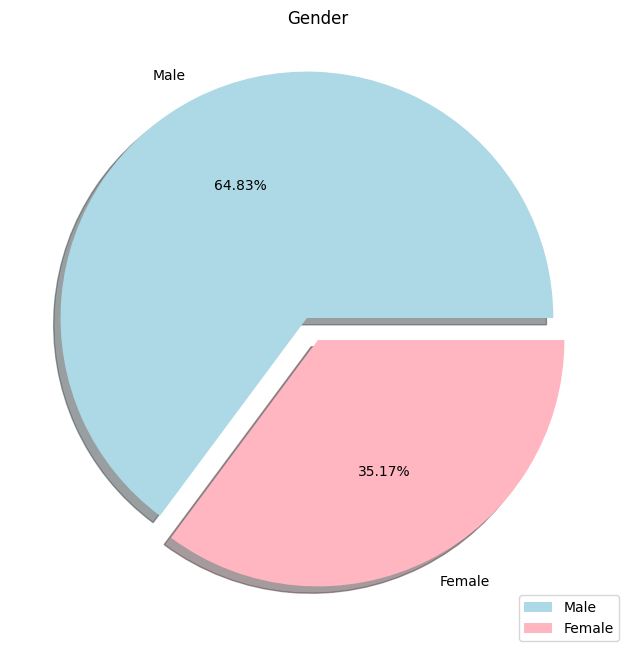

In [145]:
# Visualization
plt.figure(figsize=(5, 10))
sns.histplot(df['Target'], color="Blue")
plt.show()

plt.figure(figsize=(5, 10))
sns.countplot(data=df, x="Target").set_title('Target')
plt.show()

plt.figure(figsize=(8, 8))
plt.title("Education Status")
plt.pie(df['Target'].value_counts(), labels=['Primary School', 'Secondary School', 'Dropout'], explode=(0.1, 0.1, 0.0), autopct='%1.2f%%', shadow=True, colors=['lightblue', 'lightgreen', 'lightcoral'])
plt.legend(loc='lower right')
plt.show()

plt.figure(figsize=(8, 8))
plt.title("Gender")
plt.pie(df['Gender'].value_counts(), labels=['Male', 'Female'], explode=(0.1, 0.0), autopct='%1.2f%%', shadow=True, colors=['lightblue', 'lightpink'])
plt.legend(loc='lower right')
plt.show()

In [146]:
# Drop irrelevant target values
df = df[df['Target'] != 1]
df['Dropout'] = df['Target'].apply(lambda x: 1 if x == 0 else 0)

<ipython-input-146-8bc3246c4509>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dropout'] = df['Target'].apply(lambda x: 1 if x == 0 else 0)


In [147]:
# Standard Scaling the Data
features = ["Tuition fees up to date", "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)", "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)"]
x = df[features].values
x = StandardScaler().fit_transform(x)
y = df['Dropout'].values

# **MODEL TRAINING**

In [148]:
# Train & Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [149]:
# Function to Measure Performance
def perform(model_name, y_pred):
    print(f"Model: {model_name}")
    print("Precision : ", precision_score(y_test, y_pred, average='micro'))
    print("Recall : ", recall_score(y_test, y_pred, average='micro'))
    print("Accuracy : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", f1_score(y_test, y_pred, average='micro'))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Dropout', 'Dropout'])
    cm_display.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

Model: Gaussian Naive Bayes
Precision :  0.8471074380165289
Recall :  0.8471074380165289
Accuracy :  0.8471074380165289
F1 Score :  0.847107438016529

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.88       448
           1       0.89      0.69      0.77       278

    accuracy                           0.85       726
   macro avg       0.86      0.82      0.83       726
weighted avg       0.85      0.85      0.84       726



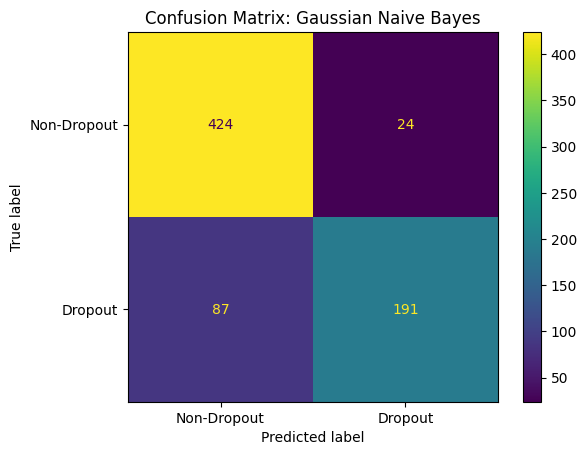

In [150]:
# Gaussian Naive Bayes
model_nb = GaussianNB()
model_nb.fit(x_train, y_train)
y_pred_nb = model_nb.predict(x_test)
perform("Gaussian Naive Bayes", y_pred_nb)

Model: Logistic Regression
Precision :  0.8870523415977961
Recall :  0.8870523415977961
Accuracy :  0.8870523415977961
F1 Score :  0.887052341597796

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       448
           1       0.90      0.79      0.84       278

    accuracy                           0.89       726
   macro avg       0.89      0.87      0.88       726
weighted avg       0.89      0.89      0.89       726



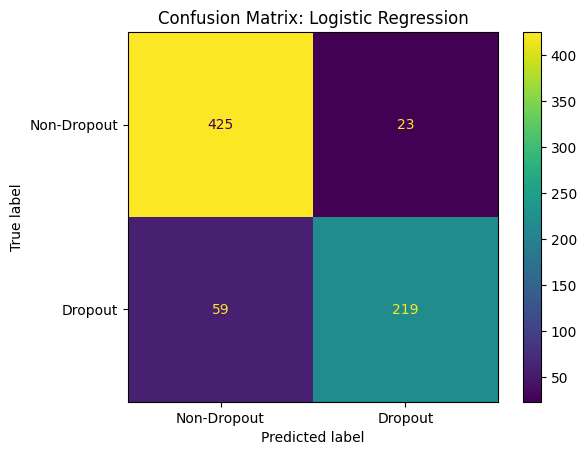

In [151]:
# Logistic Regression
model_lr = LogisticRegression()
model_lr.fit(x_train, y_train)
y_pred_lr = model_lr.predict(x_test)
perform("Logistic Regression", y_pred_lr)

Model: Random Forest
Precision :  0.8898071625344353
Recall :  0.8898071625344353
Accuracy :  0.8898071625344353
F1 Score :  0.8898071625344353

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91       448
           1       0.86      0.85      0.86       278

    accuracy                           0.89       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



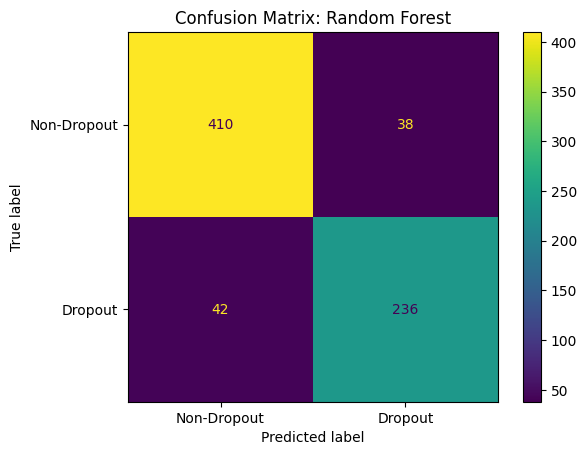

In [152]:
# Random Forest
model_rf = RandomForestClassifier(n_estimators=500, criterion='entropy')
model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)
perform("Random Forest", y_pred_rf)

Model: Support Vector Classifier
Precision :  0.8801652892561983
Recall :  0.8801652892561983
Accuracy :  0.8801652892561983
F1 Score :  0.8801652892561983

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91       448
           1       0.91      0.76      0.83       278

    accuracy                           0.88       726
   macro avg       0.89      0.86      0.87       726
weighted avg       0.88      0.88      0.88       726



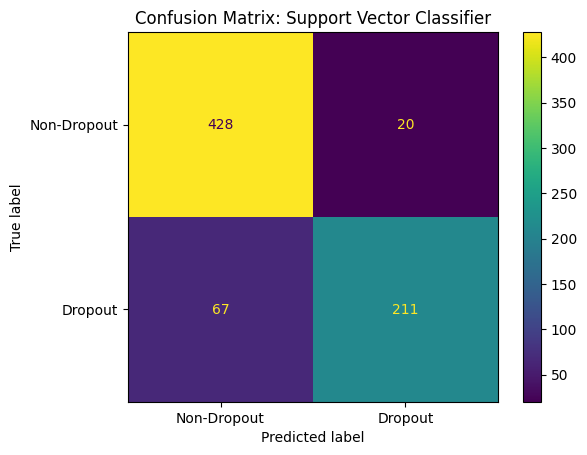

In [153]:
# Support Vector Classifier
model_svc = SVC(C=0.1, kernel='linear')
model_svc.fit(x_train, y_train)
y_pred_svc = model_svc.predict(x_test)
perform("Support Vector Classifier", y_pred_svc)

Model: Perceptron
Precision :  0.8209366391184573
Recall :  0.8209366391184573
Accuracy :  0.8209366391184573
F1 Score :  0.8209366391184573

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.77      0.84       448
           1       0.71      0.90      0.79       278

    accuracy                           0.82       726
   macro avg       0.82      0.84      0.82       726
weighted avg       0.84      0.82      0.82       726



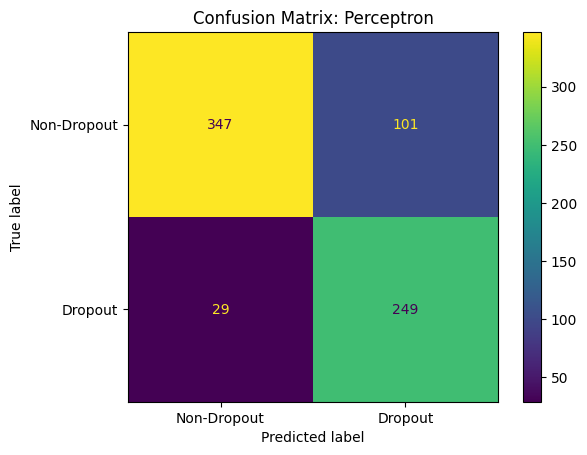

In [154]:
# Perceptron
model_mlp = Perceptron(alpha=0.001, l1_ratio=0.5, max_iter=100)
model_mlp.fit(x_train, y_train)
y_pred_mlp = model_mlp.predict(x_test)
perform("Perceptron", y_pred_mlp)

In [155]:
# KNN Classifier
knn_accuracies = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    knn_accuracies.append(accuracy_score(y_test, y_pred))

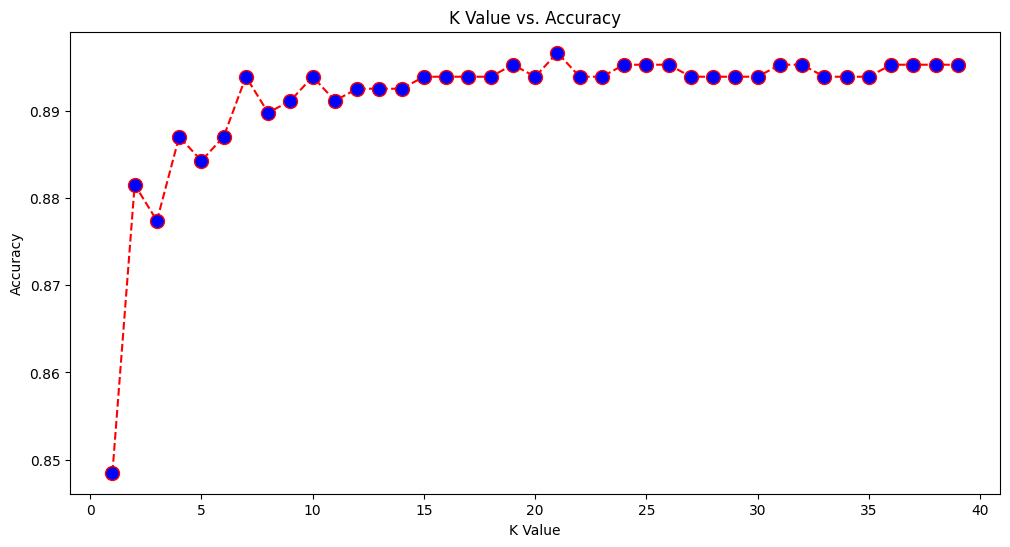

In [156]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), knn_accuracies, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('K Value vs. Accuracy')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.show()


Model: K-Nearest Neighbors
Precision :  0.8774104683195593
Recall :  0.8774104683195593
Accuracy :  0.8774104683195593
F1 Score :  0.8774104683195594

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90       448
           1       0.84      0.83      0.84       278

    accuracy                           0.88       726
   macro avg       0.87      0.87      0.87       726
weighted avg       0.88      0.88      0.88       726



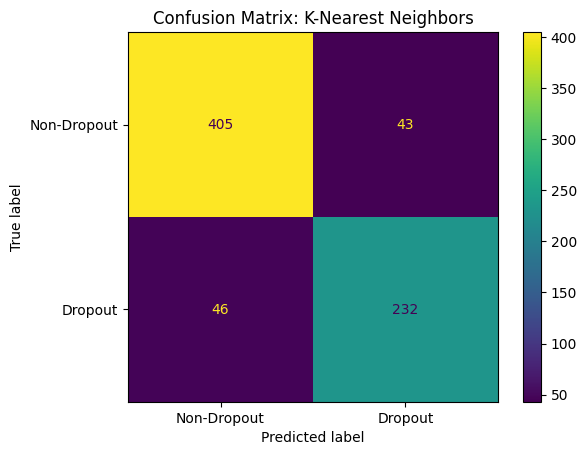

In [157]:
# Best KNN Model
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(x_train, y_train)
y_pred_knn = model_knn.predict(x_test)
perform("K-Nearest Neighbors", y_pred_knn)

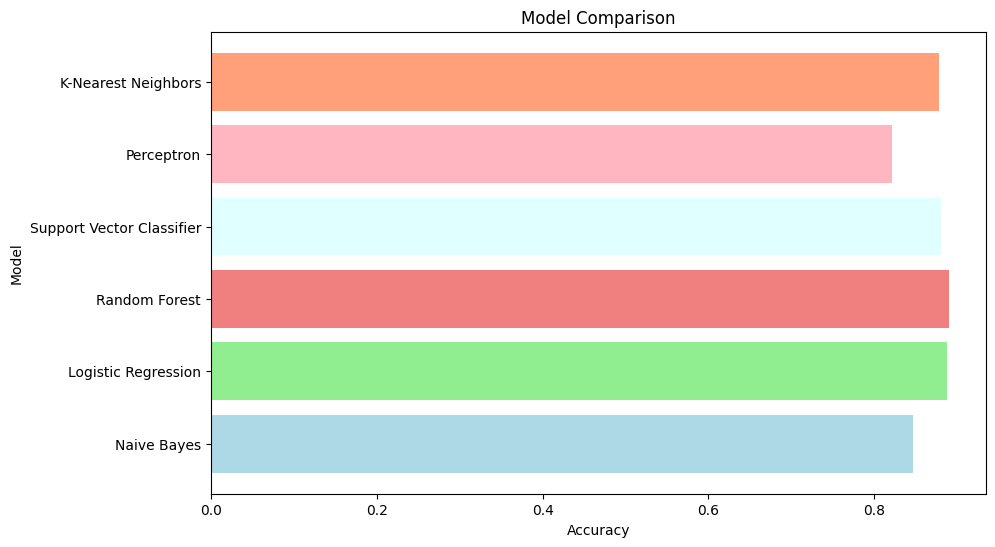

In [158]:
# Model Comparison
model_names = ["Naive Bayes", "Logistic Regression", "Random Forest", "Support Vector Classifier", "Perceptron", "K-Nearest Neighbors"]
accuracies = [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_svc), accuracy_score(y_test, y_pred_mlp), accuracy_score(y_test, y_pred_knn)]

plt.figure(figsize=(10, 6))
plt.barh(model_names, accuracies, color=['lightblue', 'lightgreen', 'lightcoral', 'lightcyan', 'lightpink', 'lightsalmon'])
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Model Comparison')
plt.show()


In [159]:
# train_model.py
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

In [160]:
# Load Data
df = pd.read_csv("Dataset.csv", sep=";")

In [161]:
# Basic Data Info
print(df.info())
print(df.describe().T)
print(df['Target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [162]:
# Encode target variable
df['Target'] = LabelEncoder().fit_transform(df['Target'])
print(df['Target'].value_counts())


Target
2    2209
0    1421
1     794
Name: count, dtype: int64


In [163]:
# Drop irrelevant target values
df = df[df['Target'] != 1]
df['Dropout'] = df['Target'].apply(lambda x: 1 if x == 0 else 0)

<ipython-input-163-8bc3246c4509>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Dropout'] = df['Target'].apply(lambda x: 1 if x == 0 else 0)


In [164]:
# Standard Scaling the Data
features = ["Tuition fees up to date", "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)", "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)"]
x = df[features].values
scaler = StandardScaler().fit(x)
x = scaler.transform(x)
y = df['Dropout'].values

In [165]:
# Train & Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [166]:
# Train Random Forest Model
model_rf = RandomForestClassifier(n_estimators=500, criterion='entropy')
model_rf.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=500)

# **PREDICTOR**

In [167]:
# Save the trained model and scaler
joblib.dump(model_rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [168]:
# predict_dropout.py
import numpy as np
import joblib

# Load the trained model and scaler
model = joblib.load('random_forest_model.pkl')
scaler = joblib.load('scaler.pkl')

def predict_dropout():
    print("Please enter the following details (values in brackets are the valid ranges):")
    tuition_fees = float(input("Tuition fees up to date (0 or 1): "))
    curricular_units_1st_approved = int(input("Curricular units 1st sem (approved) (0-10): "))
    curricular_units_1st_grade = int(input("Curricular units 1st sem (grade) (0-20): "))
    curricular_units_2nd_approved = int(input("Curricular units 2nd sem (approved) (0-10): "))
    curricular_units_2nd_grade = int(input("Curricular units 2nd sem (grade) (0-20): "))

    input_data = [tuition_fees, curricular_units_1st_approved, curricular_units_1st_grade, curricular_units_2nd_approved, curricular_units_2nd_grade]
    print(f"Input data: {input_data}")

    # Preprocess the input data
    input_data = np.array(input_data).reshape(1, -1)
    input_data = scaler.transform(input_data)

    # Predict using the loaded model
    prediction = model.predict(input_data)
    result = "Dropout" if prediction[0] == 1 else "Non-Dropout"
    print(f"The prediction for the provided data is: {result}")

# Example Usage of Real-time Prediction Function
if __name__ == "__main__":
    predict_dropout()


Please enter the following details (values in brackets are the valid ranges):
Tuition fees up to date (0 or 1): 1
Curricular units 1st sem (approved) (0-10): 10
Curricular units 1st sem (grade) (0-20): 20
Curricular units 2nd sem (approved) (0-10): 10
Curricular units 2nd sem (grade) (0-20): 20
Input data: [1.0, 10, 20, 10, 20]
The prediction for the provided data is: Non-Dropout
